# Short Demo

In [ ]:
from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

result = client.models.embed_content(
        model="gemini-embedding-001",
        contents="What is the meaning of life?")

print(result.embeddings)

[ContentEmbedding(
  values=[
    -0.022374554,
    -0.004560777,
    0.013309286,
    -0.0545072,
    -0.02090443,
    <... 3067 more items ...>,
  ]
)]


In [ ]:
result.embeddings

[ContentEmbedding(
   values=[
     -0.022374554,
     -0.004560777,
     0.013309286,
     -0.0545072,
     -0.02090443,
     <... 3067 more items ...>,
   ]
 )]

In [ ]:
embedding_for_clustering = result.embeddings[0].values
print(embedding_for_clustering)

[-0.022374554, -0.004560777, 0.013309286, -0.0545072, -0.02090443, 0.012355714, 0.015772128, 0.0054723006, 0.031729158, 0.0058553913, 0.027073925, -0.0045324513, -0.01544016, 0.031618375, 0.121548004, 0.01925409, 0.0008599909, 0.0061733276, -0.009662611, -0.015545654, 0.017062597, -0.008637558, -0.017125048, 0.0077396077, -0.0153139075, 0.011430326, 0.020329107, -0.00451, 0.024133444, 0.0070407446, 0.020197608, 0.0015623937, -0.008911156, 0.028138846, -0.017435355, -0.012656962, 0.009481721, -0.016410641, -0.015019126, 0.0144167375, -0.023614116, -0.010397569, -0.0024164703, -0.019404082, 0.019276941, -0.011112846, 0.014422737, -0.042639293, -0.014391114, 0.008184219, -0.012202394, 0.012318022, -0.010061107, -0.15826157, 0.015428178, 0.01053043, -0.0069031497, -0.010121202, -0.025695775, -0.028000489, -0.0070861652, -0.014084083, -0.008487853, -0.022122845, 0.0084621115, -0.008990799, -0.020783192, 0.010838266, 0.0013916494, 0.011982546, -0.015935048, 0.015096186, -0.0058905873, -0.013

# Iterate through df

In [ ]:
import pandas as pd
df = pd.read_csv("/content/qwen2_5_7b_instruct_noCoT_failure_analysis_645cases.csv")

In [ ]:
all_data = []
full_embedding_list = []

for i, row in df.iterrows():
    data_dict = {}

    ind = row['index']
    failed_summary = row['failure_summary']

    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=failed_summary)

    embedding_for_clustering = result.embeddings[0].values
    full_embedding_list.append(embedding_for_clustering)

    data_dict['original_index'] = ind
    data_dict['current_index'] = i
    data_dict['failed_summary'] = failed_summary
    data_dict['embedding_for_clustering'] = embedding_for_clustering

    all_data.append(data_dict)

In [ ]:
import numpy as np

embeddings_np_array = np.array(full_embedding_list)

print(f"Shape of multiple embeddings array: {embeddings_np_array.shape}")

Shape of multiple embeddings array: (645, 3072)


In [ ]:
from sklearn.cluster import KMeans

# Perform K-Means clustering
# With only one data point, n_clusters can be 1
kmeans = KMeans(n_clusters=80, random_state=0, n_init='auto')
kmeans.fit(embeddings_np_array)

KMeans(n_clusters=80, random_state=0)

In [ ]:
# Get the cluster label for the data point
cluster_label = kmeans.labels_

In [ ]:
final_dicts = []

for c_label, d_dict in zip(cluster_label, all_data):
    update_d = {}

    # Convert numpy.int32 to a standard Python int
    update_d['cluster_label'] = int(c_label)
    update_d['original_index'] = d_dict['original_index']
    update_d['current_index'] = d_dict['current_index']
    update_d['failed_summary'] = d_dict['failed_summary']
    update_d['embedding_for_clustering'] = d_dict['embedding_for_clustering']

    final_dicts.append(update_d)

In [ ]:
import json

output_filename = 'clustered_data.json'

with open(output_filename, 'w') as f:
    json.dump(final_dicts, f, indent=4)

print(f"Clustered data saved to {output_filename}")

Clustered data saved to clustered_data.json


In [ ]:
clustered_data_separated = {}

for item in final_dicts:
    cluster_id = item['cluster_label']
    if cluster_id not in clustered_data_separated:
        clustered_data_separated[cluster_id] = []
    clustered_data_separated[cluster_id].append(item)

if clustered_data_separated:
    first_cluster_id = list(clustered_data_separated.keys())[0]
    print(f"Data for Cluster {first_cluster_id}:\n")
    # Display the first few items of the first cluster for demonstration
    for i, data_item in enumerate(clustered_data_separated[first_cluster_id]):
        print(f"  Item {i+1}: Original Index={data_item['original_index']}, Failed Summary='{data_item['failed_summary'][:100]}...'\n")
        if i >= 2: # Limit to first 3 items for brevity
            break

print(f"Total unique clusters found: {len(clustered_data_separated)}")

Data for Cluster 33:

  Item 1: Original Index=0, Failed Summary='The puzzle implicitly assumes “popularity” means number sold, so from 20 bottles each and 8 juice le...'

  Item 2: Original Index=278, Failed Summary='The model likely focused on the phrase “almost half of 12 dumplings” and applied a straightforward n...'

  Item 3: Original Index=480, Failed Summary='The model likely treated “almost no coffee” as effectively zero, so it subtracted only the 6 sodas f...'

Total unique clusters found: 80


In [ ]:
output_filename = 'clustered_data_separated.json'

with open(output_filename, 'w') as f:
    json.dump(clustered_data_separated, f, indent=4)

print(f"Clustered data saved to {output_filename}")

Clustered data saved to clustered_data_separated.json


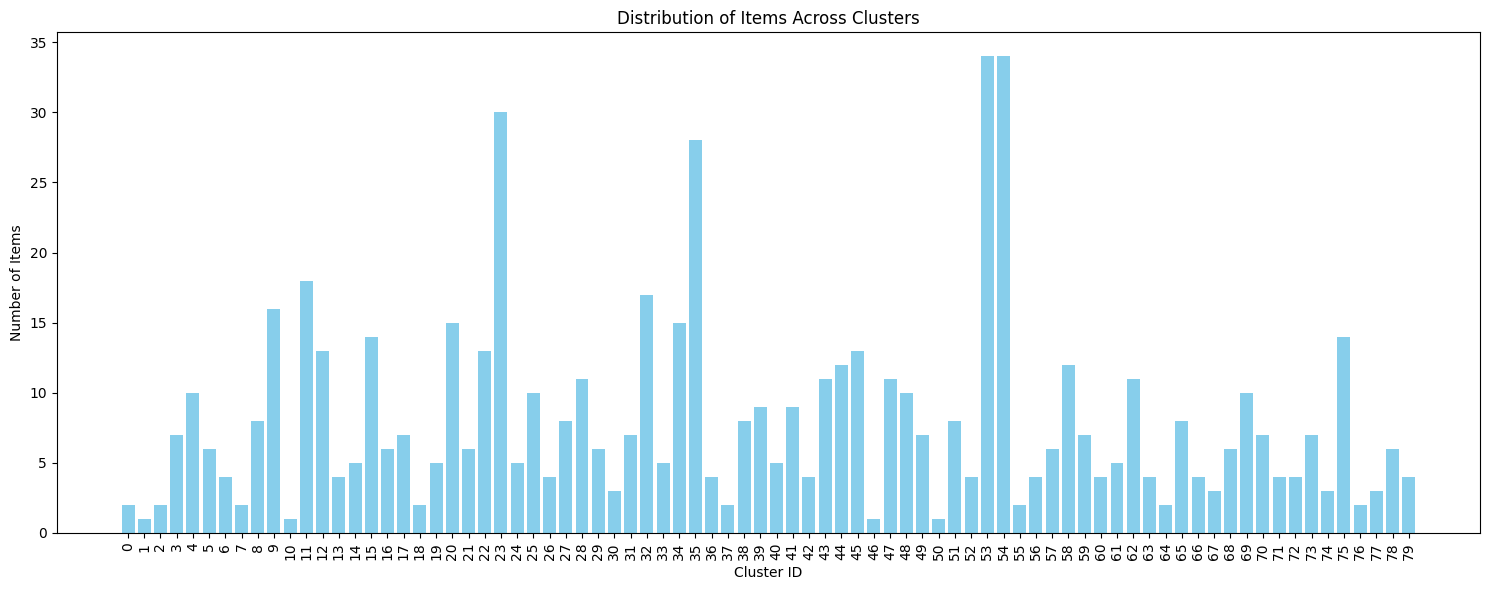

In [ ]:
import matplotlib.pyplot as plt

# Calculate the size of each cluster
cluster_sizes = {cluster_id: len(data_list) for cluster_id, data_list in clustered_data_separated.items()}

# Sort clusters by ID for consistent plotting
sorted_cluster_sizes = sorted(cluster_sizes.items())
cluster_ids = [str(item[0]) for item in sorted_cluster_sizes]
sizes = [item[1] for item in sorted_cluster_sizes]

plt.figure(figsize=(15, 6))
plt.bar(cluster_ids, sizes, color='skyblue')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.title('Distribution of Items Across Clusters')
plt.xticks(rotation=90) # Rotate x-axis labels if there are many clusters
plt.tight_layout()
plt.show()

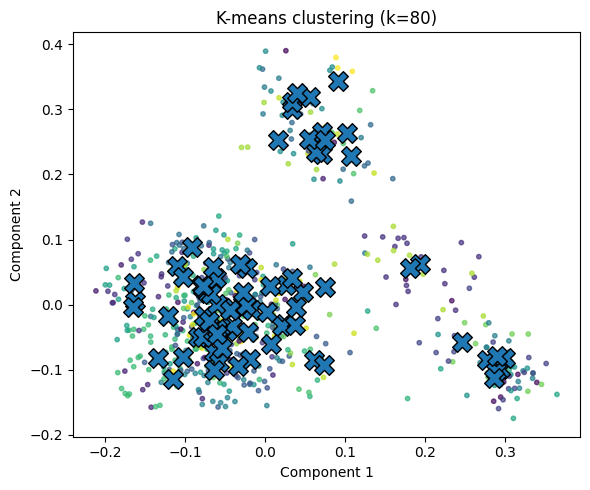

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


def plot_kmeans_clusters(embeddings: np.ndarray, kmeans: KMeans):
    """
    Plot k-means clustering result.

    - If embeddings are 2D, plot directly.
    - If embeddings are >2D, reduce to 2D using PCA and plot.
    """
    assert embeddings.ndim == 2, "embeddings must be 2D: (n_samples, n_features)"
    labels = kmeans.labels_

    n_features = embeddings.shape[1]

    if n_features == 2:
        # Directly plot 2D embeddings
        X2 = embeddings
        centers_2d = kmeans.cluster_centers_
    else:
        # Use a single PCA object for both points and centers
        pca = PCA(n_components=2)
        X2 = pca.fit_transform(embeddings)
        centers_2d = pca.transform(kmeans.cluster_centers_)

    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels,  s=10, alpha=0.7)

    plt.scatter(
        centers_2d[:, 0],
        centers_2d[:, 1],
        marker="X",
        s=200,
        edgecolor="black",
        linewidth=1.0,
    )

    plt.title(f"K-means clustering (k={kmeans.n_clusters})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.show()

plot_kmeans_clusters(embeddings_np_array, kmeans)

In [ ]:
import joblib

# Save the trained KMeans model
joblib.dump(kmeans, 'kmeans_model.joblib')
print("K-Means model saved as 'kmeans_model.joblib'")

# To load it back later:
# loaded_kmeans_model = joblib.load('kmeans_model.joblib')

K-Means model saved as 'kmeans_model.joblib'
